1- préparer les données

In [1]:
# importer pandas permet de lire un dataframe : as pd est un raccourci
import pandas as pd
# importes les librairies de visualisation. Matplotlib est la base (graphiques simples)
import matplotlib.pyplot as plt
# Seaborn construit sur matplotlib et produit des graphiques plus beaux automatiquement
import seaborn as sns

sns.set_style("whitegrid") #dit a seaborn de construire sur un fond blanc
plt.rcParams['figure.figsize'] = (10, 5) #fichier de réglages global de Matplotlib. 10cm large et 5 de haut

# Charger le dataset
df = pd.read_csv("credit_card_transactions.csv")

# 1.85M lignes — on prend un échantillon reproductible de 50 000 lignes
# random_state=42 = toujours les mêmes 50 000 lignes 
#reset_index(drop=True) = permet de remettre dans l'ordre les données (0,1,2,..)
df = df.sample(50000, random_state=42).reset_index(drop=True)

print("Dimensions :", df.shape)
print("\nColonnes disponibles :")
print(df.columns.tolist())
df.head()

Dimensions : (50000, 24)

Colonnes disponibles :
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,...,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0
1,547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,...,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN
2,110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,...,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0
3,1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,...,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN
4,271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,...,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0


On veut le nombre de valeur manquantes par colonne et le nombre de doublon 

In [2]:
print("Valeurs manquantes par colonnes:")
valeurs_nulles = df.isnull().sum()[df.isnull().sum()>0]
print(valeurs_nulles)
print("Nombre de doublons:", df.duplicated().sum())

Valeurs manquantes par colonnes:
merch_zipcode    7533
dtype: int64
Nombre de doublons: 0


2- Préparer la colonne date pour l'analyse temporelle

In [3]:
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time']) #converti en date
df['hour']=df['trans_date_trans_time'].dt.hour #extraire l'heure + créer une nouvelle colonne avec seulement l'heure
df['day_of_week']=df['trans_date_trans_time'].dt.day_name() #extraire le jour de la semaine dans une nouvelle colonne
print(df[['trans_date_trans_time','hour','day_of_week']].head())

  trans_date_trans_time  hour day_of_week
0   2020-03-09 15:09:26    15      Monday
1   2019-08-22 15:49:01    15    Thursday
2   2019-03-04 01:34:16     1      Monday
3   2020-06-16 20:04:38    20     Tuesday
4   2019-05-14 05:54:48     5     Tuesday


3- Analyse des catégories de dépenses (en nombre du plus grand au plus petit)

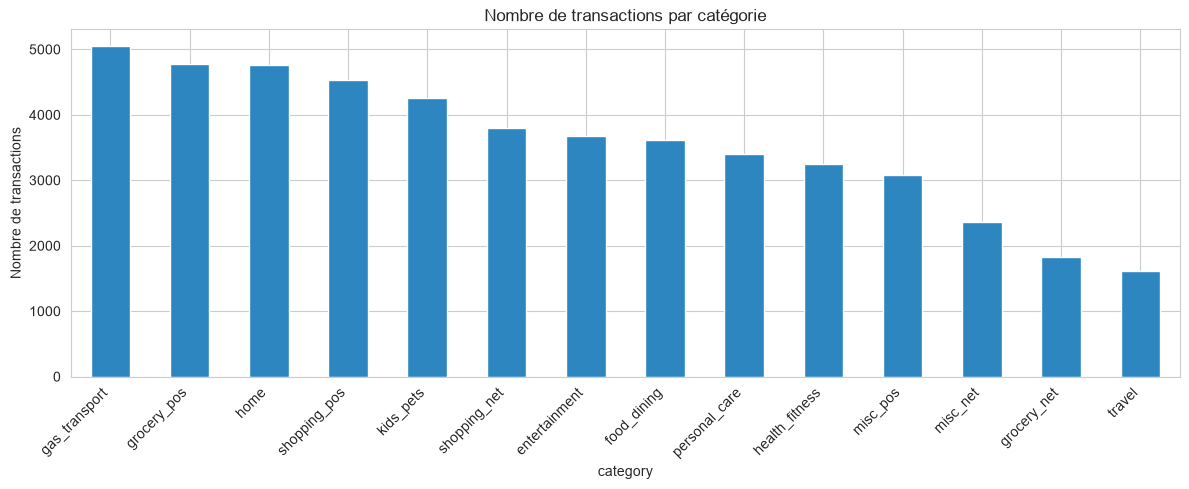

In [4]:
cat_counts=df['category'].value_counts()

plt.figure(figsize=(12, 5)) #12 large 5 haut (alternative : petit = 8,4 grand= 15,8)
cat_counts.plot(kind='bar', color='#2E86C1', edgecolor='white') #edgecolor=contour des barres
#kind = type de graphique bar= barres verticales
#kind='barh'= barres horizontales (mieux quand les labels sont longs)
#kind='line'= courbe
#kind='pie'=camembert
#kind='hist'= histogramme
plt.title("Nombre de transactions par catégorie")  # titre du graphique
plt.xlabel('category')  # légende axe X
plt.ylabel('Nombre de transactions')  # légende axe Y
plt.xticks(rotation=45, ha='right')
plt.tight_layout() #Ajuste automatiquement les marges pour que rien ne soit coupé
plt.show()

Ici on observe que les catégories avec des dépenses les + fréquentes sont l'essence et les courses. Le voyage apparait en dernière position avec les courses sur internet.

4- montant moyen par catégorie

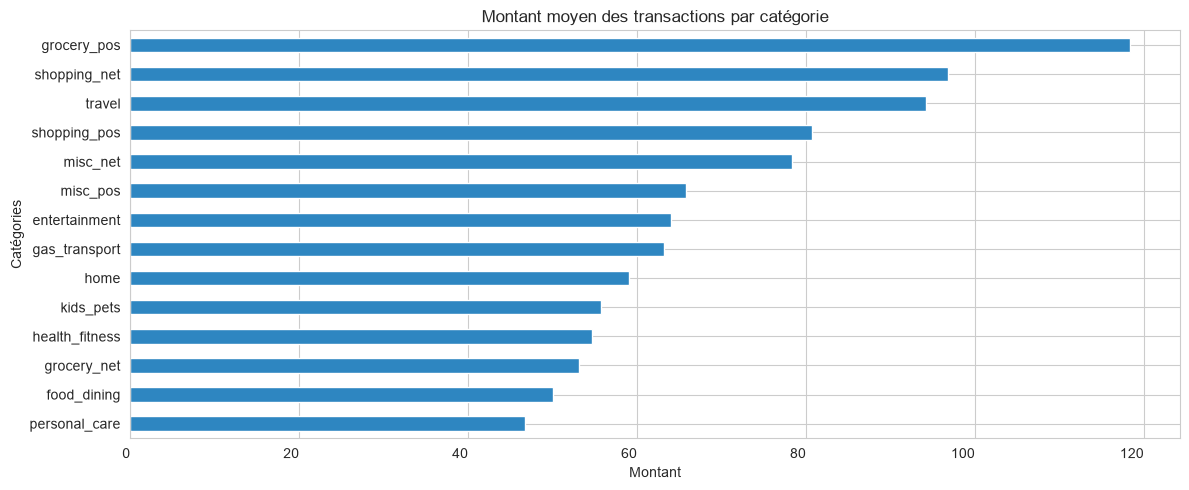

In [5]:
avg_by_cats = df.groupby('category')['amt'].mean()
avg_by_cats = avg_by_cats.sort_values(ascending=True)

plt.figure(figsize=(12, 5)) #12 large 5 haut (alternative : petit = 8,4 grand= 15,8)
avg_by_cats.plot(kind='barh', color='#2E86C1', edgecolor='white') #edgecolor=contour des barres
#kind = type de graphique bar= barres verticales
#kind='barh'= barres horizontales (mieux quand les labels sont longs)
#kind='line'= courbe
#kind='pie'=camembert
#kind='hist'= histogramme
plt.title("Montant moyen des transactions par catégorie")  # titre du graphique
plt.xlabel('Montant')  # légende axe X
plt.ylabel('Catégories')  # légende axe Y
plt.xticks(rotation=0, ha='right')
plt.tight_layout() #Ajuste automatiquement les marges pour que rien ne soit coupé
plt.show()



On constate ici que la catégorie du voayge qui était en dernière position se place en 1ère position pour le montant moyen dépensé. Ainsi, les catégories avec le plus grand nombre de dépenses ne sont pas celles avec le montant moyen le plus élevé. Cependant, un point important, les courses représentent non seulement le plus grand nombre de dépenses mais aussi le montant moyen le plus élevé.

5- moyenne des dépenses selon le genre

        Montant moyen ($)  Nb transactions  Total dépensé ($)
gender                                                       
F                   70.26            27540         1935045.85
M                   70.82            22460         1590648.82


C:\Users\rosea\AppData\Local\Temp\ipykernel_16052\2592371993.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='amt', palette=['#2E86C1', 'pink'])


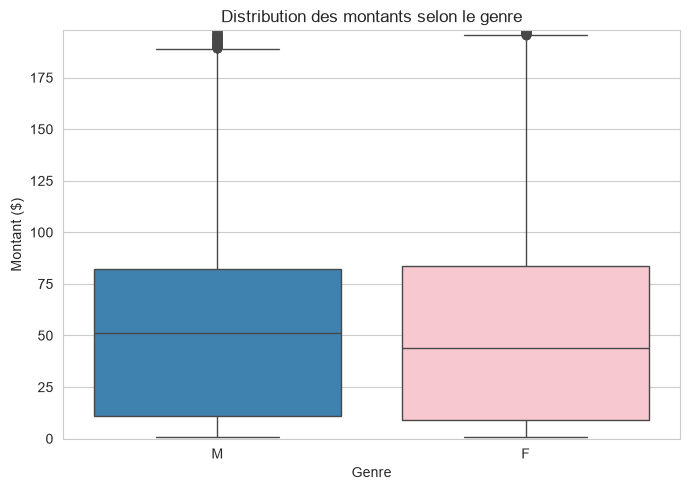

In [30]:
avg_by_gender = df.groupby('gender')['amt'].agg(['mean', 'count', 'sum']).round(2)
avg_by_gender.columns = ['Montant moyen ($)', 'Nb transactions', 'Total dépensé ($)']
print(avg_by_gender)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='gender', y='amt', palette=['#2E86C1', 'pink'])
plt.title("Distribution des montants selon le genre")
plt.xlabel("Genre")
plt.ylabel("Montant ($)")
plt.ylim(0, df['amt'].quantile(0.95))  # retire les valeurs extrêmes pour la lisibilité
plt.tight_layout()
plt.show()

Contrairement à ce qu'on pourrait penser, on constate qu'il n'y a pas de grande différence entre les dépenses moyennes des hommes et des femmes. Ils sont tous 2 proche de 70 (70.26 pour les femmes et 70.82 pour les hommes). Cependant, on constate que la médiane pour les hommes est plus importante que celle des femmes, environ 51-52$ contre environ 45$ pour les femmes. Ce qui signifie que les dépenses des femmes sont plus régulières que celles des hommes.

6- transactions par heure

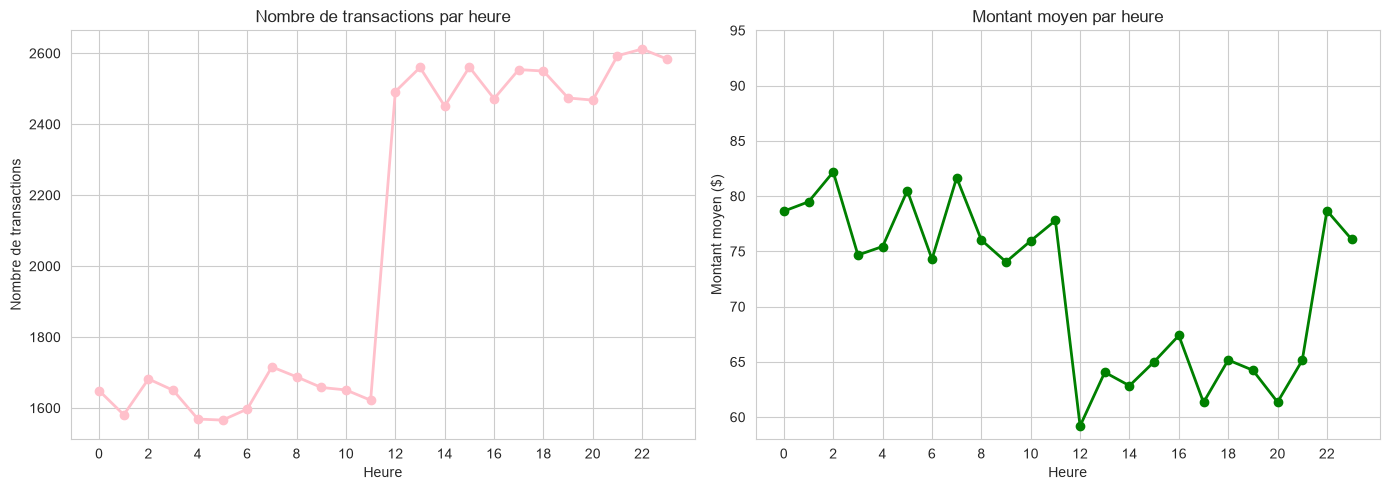

In [31]:
transactions_per_hour = df.groupby('hour')['amt'].agg(['count','mean'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 — gauche
transactions_per_hour['count'].plot(ax=ax1, kind='line', marker='o', color='pink', linewidth=2)
ax1.set_title('Nombre de transactions par heure')
ax1.set_xlabel('Heure')
ax1.set_ylabel('Nombre de transactions')
ax1.set_xticks(range(0, 24, 2))

# Graphique 2 — droite
transactions_per_hour['mean'].plot(ax=ax2, kind='line', marker='o', color='green', linewidth=2)
ax2.set_title('Montant moyen par heure')
ax2.set_xlabel('Heure')
ax2.set_ylabel('Montant moyen ($)')
ax2.set_xticks(range(0, 24, 2))
ax2.set_yticks(range(60, 100, 5))

plt.tight_layout()
plt.show()

We can see that between midnight and 11 AM there are few transactions,no hour exceed 1,700 transactions and a local peak at 7 AM. However, at 12PM, activity rises and reaches 2,500 transactions.
 The daily peak occurs at 10PM with approximatly 2,600 transactions. Moreover, in the afternoon, transaction volumes never fall below 2,450 transactions per hour, confirming that this is the busiest period of the day alongside the evening peak


Like we have seen for the categories, the hours which have the highest number of transaction are not those with the highest average amounts. In fact, between 12 PM and 9 PM, when transactions volume are at their peak, the amounts of transaction are at their lowest, not exceeding 67$. However, between 10 PM and 11 AM, when fewer transactions occur, average amounts never falls below 74$. The peak is reached at 2AM and 7 AM with 83$. This suggests that daytime transactions tend to be frequent but small (everyday purchases), while late-night and early-morning transactions are rarer but of higher value.

7-  transactions par jour de la semaine

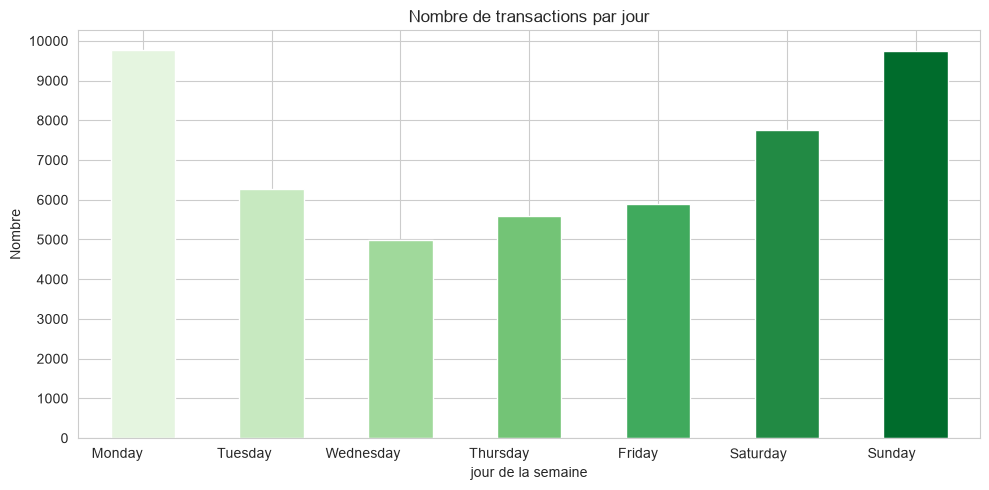

day_of_week
Monday       9774
Tuesday      6261
Wednesday    4990
Thursday     5582
Friday       5903
Saturday     7756
Sunday       9734
Name: amt, dtype: int64


In [8]:
day_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = sns.color_palette("Greens", 7)

transactions_per_day = df.groupby('day_of_week')['amt'].count().reindex(day_order)
plt.figure(figsize=(10, 5))
transactions_per_day.plot(kind='bar', color=colors, edgecolor='white')
#sns.color_palette("pastel", 7)= couleurs douces/claires 
#sns.color_palette("muted", 7) = couleurs atténuées
#sns.color_palette("husl", 7)  = couleurs vives bien espacées
#sns.color_palette("Blues", 7) = dégradé de bleus
#sns.color_palette("Set2", 7)  = palette colorée classique
plt.title('Nombre de transactions par jour')
plt.xlabel('jour de la semaine')
plt.ylabel('Nombre')
plt.xticks(rotation=0, ha='right')
plt.yticks(range(0,11000,1000))
plt.tight_layout()
plt.show()
print(transactions_per_day)



The weekly peak is reached on Monday with 9,774 transactions closely followed by Sunday with 9,734. 
These two days are by far the busiest of the week. Indeed, the others don't exceed 7,756 reached on Saturday. Therefore, we can see that on the first day of the week there are a lot of transactions realised which then drops at 4,990 on Wednesday and increase sharply on Saturday.

8- COMMENTS

This analysis shows us that the categories with the highest number of transactions are not necessarily the categories with the higher amount. Moreover, we have seen the gender has no significant impact on the transaction habits. However, we have observed that the transactions really depend on the hour in a day and the day of the week. Indeed, we have seen that most of the transactions occur in the afternoon to the evening and especially on Mondays and the weekend.